# Frictionless Convergence Validation

Before relying on the hedging engine for the strategy research, I want to check one basic numerical property. With transaction costs removed and the hedge reset to the Black–76 delta at every grid point, a finer time grid should make terminal hedging error shrink.

For a standard discrete delta hedge, the first-order benchmark is

$$
\operatorname{Std}(\mathrm{P\&L}) \propto N^{-1/2},
$$

while the mean terminal hedging P&L should remain compatible with zero,

$$
\mathbb{E}[\mathrm{P\&L}] \approx 0.
$$

Here $N$ is the number of rebalancing steps. These are the two checks used below.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from dynamic_delta_hedging.config import HedgingConfig
from dynamic_delta_hedging.convergence import (
    create_convergence_table,
    run_frictionless_convergence,
)
from dynamic_delta_hedging.presentation import (
    SEMANTIC_GRAY,
    SEMANTIC_GREEN,
    SEMANTIC_RED,
    style_convergence_rate_summary,
)

FIGURE_SIZE = (7.2, 4.4)


## 1. Frictionless setup

The contract assumptions stay fixed while only the rebalancing grid changes. Both bid–ask spreads and the futures drift are set to zero, so the remaining terminal P&L comes from discrete hedging rather than execution costs or a directional drift assumption.

$$
s_F=0, \qquad s_O=0, \qquad \mu=0.
$$


In [2]:
# User-configurable convergence inputs

F0 = 100.0                 # Initial futures price
K = 100.0                  # Option strike price
T = 0.5                    # Time to maturity in years
R = 0.03                   # Annual risk-free interest rate
SIGMA = 0.25               # Black-76 volatility
N_PATHS = 10_000           # Monte Carlo paths per grid
SEED = 42                  # Random seed for reproducibility

CONVERGENCE_N_STEPS_VALUES = [4, 8, 16, 32, 64, 128, 256]  # Rebalancing grids to test

config = HedgingConfig(
    F0=F0,
    K=K,
    T=T,
    r=R,
    sigma=SIGMA,
    futures_spread=0.0,
    option_spread=0.0,
    n_steps=CONVERGENCE_N_STEPS_VALUES[0],
    n_paths=N_PATHS,
    mu=0.0,
    seed=SEED,
)


## 2. Run the convergence experiment

For every value of $N$, a new set of futures paths is simulated and the hedge is rebalanced at every available time step. The pricing model and contract assumptions do not change between grids.


In [3]:
convergence_results = run_frictionless_convergence(
    base_config=config,
    n_steps_values=CONVERGENCE_N_STEPS_VALUES,
    n_paths=N_PATHS,
    seed=SEED,
    verbose=False,
)

convergence_table = create_convergence_table(convergence_results)

convergence_table["zero_inside_95_ci"] = (
    (convergence_table["ci_lower_95"] <= 0.0)
    & (convergence_table["ci_upper_95"] >= 0.0)
)


## 3. Convergence results

The useful checks are compact. P&L dispersion should fall as $N$ increases, while the confidence interval around mean terminal P&L should continue to include zero.


In [4]:
results_table = pd.DataFrame(
    {
        "Steps": convergence_table["n_steps"].astype(int),
        "Δt": convergence_table["dt"],
        "Mean P&L": convergence_table["mean_pnl"],
        "95% CI": [
            f"[{lower:.5f}, {upper:.5f}]"
            for lower, upper in zip(
                convergence_table["ci_lower_95"],
                convergence_table["ci_upper_95"],
            )
        ],
        "Zero in 95% CI": convergence_table["zero_inside_95_ci"].map(
            {True: "✓ Yes", False: "✗ No"}
        ),
        "P&L Std ↓": convergence_table["std_pnl"],
    }
)

def _status_style(value):
    color = SEMANTIC_GREEN if value == "✓ Yes" else SEMANTIC_RED
    return f"background-color: {color}; color: white; font-weight: 700;"

neutral_columns = ["Steps", "Δt", "Mean P&L", "95% CI", "P&L Std ↓"]

styled_results = (
    results_table.style
    .hide(axis="index")
    .format(
        {
            "Steps": "{:,.0f}",
            "Δt": "{:.6f}",
            "Mean P&L": "{:.5f}",
            "P&L Std ↓": "{:.4f}",
        }
    )
    .set_properties(
        subset=neutral_columns,
        **{
            "background-color": SEMANTIC_GRAY,
            "color": "white",
            "font-weight": "700",
        },
    )
    .map(_status_style, subset=["Zero in 95% CI"])
    .set_table_styles(
        [
            {"selector": "table", "props": [("border-collapse", "collapse")]},
            {
                "selector": "th",
                "props": [
                    ("background-color", "#eeeeee"),
                    ("font-weight", "bold"),
                    ("text-align", "center"),
                    ("border", "1px solid #b7b7b7"),
                    ("padding", "7px"),
                    ("white-space", "nowrap"),
                ],
            },
            {
                "selector": "td",
                "props": [
                    ("padding", "6px 9px"),
                    ("border", "1px solid #b7b7b7"),
                    ("text-align", "center"),
                ],
            },
        ]
    )
    .set_caption("Frictionless convergence results")
)

display(styled_results)


Steps,Δt,Mean P&L,95% CI,Zero in 95% CI,P&L Std ↓
4,0.125000,-0.04698,"[-0.10329, 0.00933]",✓ Yes,2.8727
8,0.062500,-0.02694,"[-0.06759, 0.01370]",✓ Yes,2.0737
16,0.031250,-0.02553,"[-0.05503, 0.00397]",✓ Yes,1.5050
32,0.015625,-0.00560,"[-0.02651, 0.01531]",✓ Yes,1.0668
64,0.007812,-0.01222,"[-0.02716, 0.00271]",✓ Yes,0.7620
128,0.003906,0.00572,"[-0.00495, 0.01640]",✓ Yes,0.5447
256,0.001953,-0.00095,"[-0.00844, 0.00653]",✓ Yes,0.3819


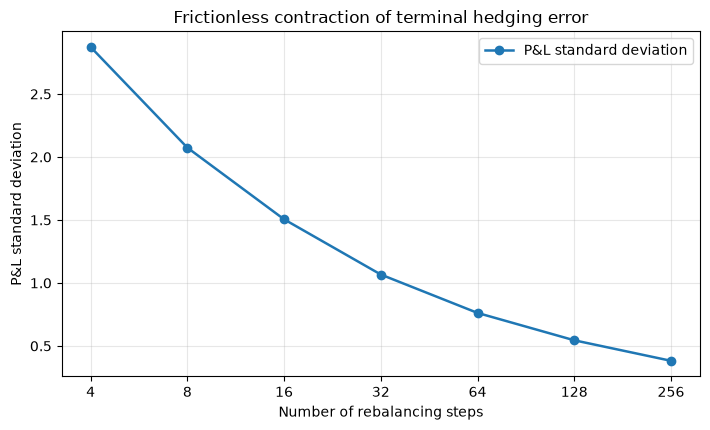

In [5]:
n_steps_values = convergence_table["n_steps"].to_numpy(dtype=float)
std_values = convergence_table["std_pnl"].to_numpy(dtype=float)

figure, axis = plt.subplots(figsize=FIGURE_SIZE)

axis.plot(
    n_steps_values,
    std_values,
    marker="o",
    linewidth=1.8,
    label="P&L standard deviation",
)

axis.set_xscale("log", base=2)
axis.set_xticks(n_steps_values)
axis.set_xticklabels([f"{int(value)}" for value in n_steps_values])
axis.set_xlabel("Number of rebalancing steps")
axis.set_ylabel("P&L standard deviation")
axis.set_title("Frictionless contraction of terminal hedging error")
axis.grid(visible=True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


## 4. Empirical convergence rate

A falling standard deviation is the first check. The stronger test is whether it falls at roughly the rate predicted by discrete delta-hedging theory. I estimate that rate from

$$
\log\!\left(\operatorname{Std}(\mathrm{P\&L})\right)
=
a+b\log N,
$$

with the theoretical benchmark

$$
b=-\frac{1}{2}.
$$


Diagnostic,Value
Estimated log-log slope,-0.4847
Theoretical slope,-0.5000
R²,0.9998


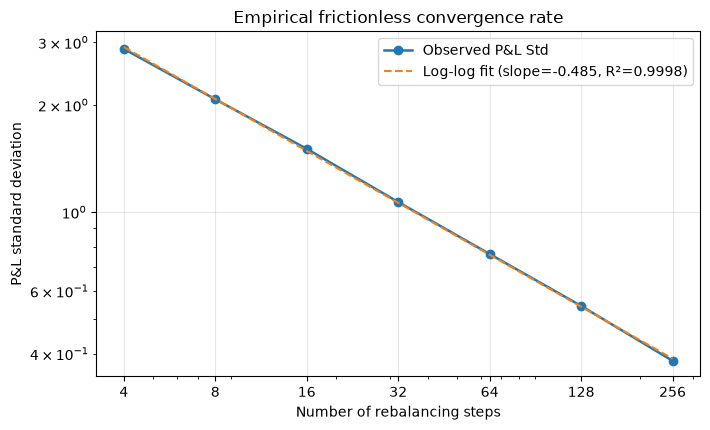

In [6]:
log_n_steps = np.log(n_steps_values)
log_std_pnl = np.log(std_values)

slope, intercept = np.polyfit(
    log_n_steps,
    log_std_pnl,
    deg=1,
)

fitted_log_std = intercept + slope * log_n_steps
residual_sum_of_squares = np.sum(
    (log_std_pnl - fitted_log_std) ** 2
)
total_sum_of_squares = np.sum(
    (log_std_pnl - np.mean(log_std_pnl)) ** 2
)
r_squared = 1.0 - residual_sum_of_squares / total_sum_of_squares

rate_summary = pd.DataFrame(
    {
        "Diagnostic": [
            "Estimated log-log slope",
            "Theoretical slope",
            "R²",
        ],
        "Value": [
            slope,
            -0.5,
            r_squared,
        ],
    }
)

display(style_convergence_rate_summary(rate_summary))

fitted_std_values = np.exp(intercept) * n_steps_values ** slope

figure, axis = plt.subplots(figsize=FIGURE_SIZE)

axis.loglog(
    n_steps_values,
    std_values,
    marker="o",
    linewidth=1.8,
    label="Observed P&L Std",
)

axis.loglog(
    n_steps_values,
    fitted_std_values,
    linestyle="--",
    linewidth=1.5,
    label=f"Log-log fit (slope={slope:.3f}, R²={r_squared:.4f})",
)

axis.set_xticks(n_steps_values)
axis.set_xticklabels([f"{int(value)}" for value in n_steps_values])
axis.set_xlabel("Number of rebalancing steps")
axis.set_ylabel("P&L standard deviation")
axis.set_title("Empirical frictionless convergence rate")
axis.grid(visible=True, alpha=0.3)
axis.legend()

figure.tight_layout()
plt.show()


The convergence check is deliberately limited to these results. The mean P&L tests for persistent bias, the standard deviation shows whether hedging error contracts, and the log–log fit checks whether that contraction is close to the theoretical $N^{-1/2}$ rate.
